# TAHAP 4 — Uji Kompatibilitas Model Penuh

Tahap ini **tidak memilih nilai parameter**. Keputusannya biner per tahap: pertahankan hasil
kalibrasi parsial, atau kembalikan ke nilai turunan data.

**Yang dibandingkan:** himpunan parameter **v2** (sebelum kalibrasi) dan **v3** (setelah kalibrasi Tahap 2,
Laju Konversi Dasar 0,0638662). Tahap 1 dan Tahap 3 tidak mengubah nilai apa pun.

**Himpunan evaluasi seragam:** {2019, 2022, 2023, 2024, 2025} untuk uji B — periode objektif per
subsistem tidak dipakai di sini karena irisannya dengan jendela uji B tidak memadai
(periode P5 2016–2019 hanya beririsan di 2019, yang merupakan nilai awal).

**Pemicu penolakan** (ambang 5% yang sama dengan R1–R4):

| Kode | Pemicu |
|---|---|
| M1 | NRMSE variabel target tahap *k* di uji B > 1,05 × baseline v2 |
| M2 | Rata-rata NRMSE 9 variabel uji B > 1,05 × baseline v2 |
| S | Uji ekstrem menjadi GAGAL, atau aturan fisik dilanggar di BASE |
| T | Horizon 2150 tidak stabil, atau syarat stabil dilanggar |

Parameter ditolak hanya bila pemicu terbukti teratribusi ke tahapnya. Penurunan kategori DC,
perubahan status tren, dan pemburukan satu variabel nontarget **bukan** dasar penolakan, hanya dilaporkan.

In [1]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 29.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
from scipy import stats
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
V2 = FOLDER / "V2 Sebelum Kalibrasi"     # file dengan Laju Konversi Dasar 0,0436052
V3 = FOLDER / "V3 Setelah Kalibrasi"     # file dengan Laju Konversi Dasar 0,0638662

FILE = {"B":"Uji B.mdl", "P1":"Uji Parsial P1 & P4 V2.mdl", "P1b":"UJI Parsial P1b v2.mdl",
        "FINAL":"MODEL SISTEM DINAMIS.mdl"}

DATA = pd.DataFrame({
 "Jumlah Wisatawan":[6413735,6551294,6644412,7996959,20520104,19610135,22849394.5,25755726,30542580,38134536,40695654],
 "Jumlah Hotel dan Akomodasi":[1165,1170,1179,1617,1817,1848,1696,1818,1820,2000,2291],
 "Jumlah Objek Daya Tarik Wisata":[165,158,171,177,189,180,170,183,201,218,201],
 "Tenaga Kerja Pariwisata":[254537,263878,273563,354684,334784,313840,310755,395284,359340,350946,364994],
 "Lahan Terbangun":[43037.00491,44561.0784555117,50223.957001398,56624.3602289948,63480.0442236269,
                    58962.0411105434,59887.5260314565,57709.075808398,75624.403529316,73511.574651116,55029.5352961885],
 "TPK":[0.3489,0.3772,0.4508,0.4511,0.4534,0.2890,0.2748,0.4499,0.4477,0.4217,0.3807],
 "PDRB Sektor Pariwisata":[10131.09,10694.03,11347.59,12100.99,13104.38,10926.83,12097.19,13672.58,14809.20,15873.81,16947.62],
 "Investasi Sektor Pariwisata":[53.0896,373.8424,165.3915,568.3341,741.4483,489.6932,848.8042,463.5886,1175.2552,712.2835,1325.950399],
 "Total Malam Menginap":[5698325,6097324,10899900,10293319,13363923,4753098,7379577,9267217,11417702,11503540,11954114]},
 index=np.arange(2015, 2026))

KOLOM_B = list(DATA.columns)
EVAL_B  = np.array([2019, 2022, 2023, 2024, 2025])     # himpunan evaluasi seragam
OBJ_P1  = np.array([2016,2017,2018,2019,2023,2024,2025])
OBJ_P4  = np.array([2016,2017,2018,2019,2022,2023,2024,2025])

In [8]:
def nrmse(sim, act):
    return np.sqrt(np.mean((sim-act)**2)) / act.mean()

def statistik(sim, act, t):
    e = sim-act; SA, SS, SE = act.std(), sim.std(), e.std()
    la, ls = stats.linregress(t, act), stats.linregress(t, sim); n = len(t)
    th = abs(ls.slope-la.slope)/np.sqrt(la.stderr**2+ls.stderr**2); tt = stats.t.ppf(0.975, 2*n-4)
    tren = ("Berlawanan arah" if np.sign(ls.slope) != np.sign(la.slope)
            else ("Berbeda nyata" if th > tt else "Tidak berbeda nyata"))
    return {"Tren":tren, "E1":abs(sim.mean()-act.mean())/abs(act.mean()),
            "E2":abs(SS-SA)/SA, "DC":SE/(SA+SS)}

def jalankan(berkas, tahun_awal, kolom, final_time=2025):
    m = pysd.read_vensim(str(berkas))
    tpk = [k for k in m.namespace if "TPK" in k and "Ambang" not in k][0]
    kol = [tpk if x == "TPK" else x for x in kolom]
    r = m.run(return_columns=kol, final_time=final_time,
              return_timestamps=list(range(tahun_awal, final_time+1)))
    return r.apply(lambda s: np.real(s.astype(complex))).rename(columns={tpk:"TPK"})

## Pemicu M1 dan M2 — uji B, serta re-run P1, P4, P1b

In [9]:
rows = []

b2 = jalankan(V2/FILE["B"], 2019, KOLOM_B)
b3 = jalankan(V3/FILE["B"], 2019, KOLOM_B)
for v in KOLOM_B:
    a = DATA[v].loc[EVAL_B].values
    n2, n3 = nrmse(b2[v].loc[EVAL_B].values, a), nrmse(b3[v].loc[EVAL_B].values, a)
    t = np.arange(2019, 2026); aa = DATA[v].loc[2019:].values
    s2, s3 = statistik(b2[v].loc[2019:].values, aa, t), statistik(b3[v].loc[2019:].values, aa, t)
    rows.append({"Uji":"B", "Variabel":v, "NRMSE v2":n2, "NRMSE v3":n3, "Rasio v3/v2":n3/n2,
                 "Memburuk material (>1,05)":n3 > 1.05*n2, "DC v2":s2["DC"], "DC v3":s3["DC"],
                 "Tren v2":s2["Tren"], "Tren v3":s3["Tren"]})

KOL_P = ["Jumlah Hotel dan Akomodasi", "TPK", "Lahan Terbangun"]
for uji, berkas, var, obj in [("P1", FILE["P1"], "Jumlah Hotel dan Akomodasi", OBJ_P1),
                              ("P1 (TPK)", FILE["P1"], "TPK", OBJ_P1),
                              ("P4", FILE["P1"], "Lahan Terbangun", OBJ_P4),
                              ("P1b", FILE["P1b"], "Jumlah Hotel dan Akomodasi", OBJ_P1)]:
    r2, r3 = jalankan(V2/berkas, 2016, KOL_P), jalankan(V3/berkas, 2016, KOL_P)
    a = DATA[var].loc[obj].values
    n2, n3 = nrmse(r2[var].loc[obj].values, a), nrmse(r3[var].loc[obj].values, a)
    t = np.arange(2016, 2026); aa = DATA[var].loc[2016:].values
    s2, s3 = statistik(r2[var].loc[2016:].values, aa, t), statistik(r3[var].loc[2016:].values, aa, t)
    rows.append({"Uji":uji, "Variabel":var, "NRMSE v2":n2, "NRMSE v3":n3, "Rasio v3/v2":n3/n2,
                 "Memburuk material (>1,05)":n3 > 1.05*n2, "DC v2":s2["DC"], "DC v3":s3["DC"],
                 "Tren v2":s2["Tren"], "Tren v3":s3["Tren"]})

tabel = pd.DataFrame(rows)
bmask = tabel["Uji"] == "B"
m1 = tabel.loc[bmask & (tabel.Variabel == "Lahan Terbangun"), "Rasio v3/v2"].iloc[0]
m2 = tabel.loc[bmask, "NRMSE v3"].mean() / tabel.loc[bmask, "NRMSE v2"].mean()
print(f"M1 (Lahan Terbangun di uji B): rasio {m1:.4f} -> {'AKTIF' if m1 > 1.05 else 'tidak aktif'}")
print(f"M2 (rata-rata 9 variabel)    : rasio {m2:.4f} -> {'AKTIF' if m2 > 1.05 else 'tidak aktif'}")
tabel.round(4)

M1 (Lahan Terbangun di uji B): rasio 1.3241 -> AKTIF
M2 (rata-rata 9 variabel)    : rasio 1.0279 -> tidak aktif


,Uji,Variabel,NRMSE v2,NRMSE v3,Rasio v3/v2,"Memburuk material (>1,05)",DC v2,DC v3,Tren v2,Tren v3
0,B,Jumlah Wisatawan,0.2233,0.2254,1.0096,False,0.4482,0.4537,Berbeda nyata,Berbeda nyata
1,B,Jumlah Hotel dan Akomodasi,0.2099,0.2104,1.0027,False,0.8228,0.8245,Berlawanan arah,Berlawanan arah
2,B,Jumlah Objek Daya Tarik Wisata,0.0625,0.0626,1.0007,False,0.7855,0.7863,Tidak berbeda nyata,Tidak berbeda nyata
3,B,Tenaga Kerja Pariwisata,0.1897,0.1897,1.0000,False,0.8860,0.8860,Berlawanan arah,Berlawanan arah
4,B,Lahan Terbangun,0.1796,0.2378,1.3241,True,0.6619,0.6406,Tidak berbeda nyata,Tidak berbeda nyata
5,B,TPK,0.2986,0.2991,1.0015,False,0.6224,0.6230,Tidak berbeda nyata,Tidak berbeda nyata
6,B,PDRB Sektor Pariwisata,0.2778,0.2793,1.0054,False,0.3062,0.3112,Tidak berbeda nyata,Tidak berbeda nyata
7,B,Investasi Sektor Pariwisata,0.5203,0.5215,1.0024,False,0.7356,0.7386,Tidak berbeda nyata,Tidak berbeda nyata
8,B,Total Malam Menginap,0.3741,0.3751,1.0027,False,0.7041,0.7071,Tidak berbeda nyata,Tidak berbeda nyata
9,P1,Jumlah Hotel dan Akomodasi,0.1041,0.1041,1.0000,False,0.2476,0.2476,Tidak berbeda nyata,Tidak berbeda nyata


## Diagnosis bila M1 aktif — deret Lahan Terbangun di uji B

,Data,"v2 (k = 0,0436052)","v3 (k = 0,0638662)"
2019,63480.0,63480.0,63480.0
2020,58962.0,65699.0,66727.0
2021,59888.0,67975.0,70097.0
2022,57709.0,70309.0,73590.0
2023,75624.0,72705.0,77208.0
2024,73512.0,75161.0,80951.0
2025,55030.0,77678.0,84817.0


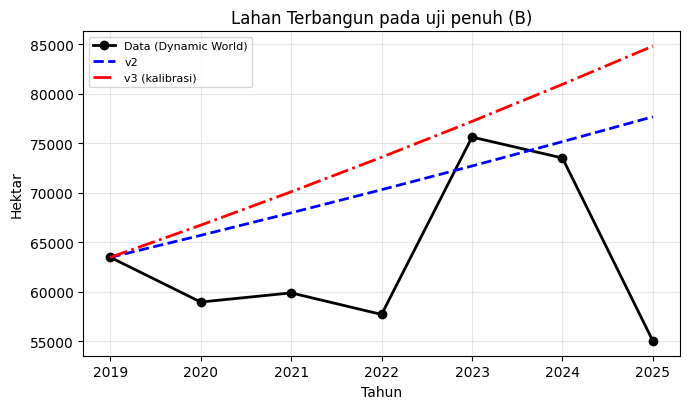

In [10]:
banding_lahan = pd.DataFrame({
    "Data": DATA["Lahan Terbangun"].loc[2019:],
    "v2 (k = 0,0436052)": b2["Lahan Terbangun"],
    "v3 (k = 0,0638662)": b3["Lahan Terbangun"]})
display(banding_lahan.round(0))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(banding_lahan.index, banding_lahan["Data"], "ko-", lw=2, label="Data (Dynamic World)")
ax.plot(banding_lahan.index, banding_lahan["v2 (k = 0,0436052)"], "b--", lw=2, label="v2")
ax.plot(banding_lahan.index, banding_lahan["v3 (k = 0,0638662)"], "r-.", lw=2, label="v3 (kalibrasi)")
ax.set_xlabel("Tahun"); ax.set_ylabel("Hektar"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Lahan Terbangun pada uji penuh (B)")
fig.tight_layout(); fig.savefig(FOLDER / "tahap4_lahan_uji_B.png", dpi=150); plt.show()

## Pemicu S dan T — hanya dijalankan bila M1 dan M2 tidak aktif

Kalau kalibrasi sudah ditolak oleh M1, himpunan parameter final kembali sama dengan v2,
sehingga BASE, 17 uji ekstrem, dan uji horizon versi v2 tetap berlaku dan tidak perlu diulang.

In [11]:
LUAS = 317036
if m1 <= 1.05 and m2 <= 1.05:
    VAR = ["Jumlah Wisatawan","Daya Tarik Destinasi Wisata","Rasio Daya Dukung Lahan","Lahan Terbangun",
           "Jumlah Hotel dan Akomodasi","Jumlah Objek Daya Tarik Wisata","Tenaga Kerja Pariwisata",
           "PDRB Sektor Pariwisata","Investasi Sektor Pariwisata"]
    base3 = jalankan(V3/FILE["FINAL"], 2025, VAR, final_time=2050)
    hor3  = jalankan(V3/FILE["FINAL"], 2025, VAR, final_time=2150)
    print("BASE v3 2050:"); display(base3.loc[2050].round(3))
    print("Horizon 2150 — puncak wisatawan:",
          f"{hor3['Jumlah Wisatawan'].max()/1e6:,.2f} juta pada {hor3['Jumlah Wisatawan'].idxmax():.0f}")
    print("Aturan fisik di BASE: lahan maks",
          f"{base3['Lahan Terbangun'].max():,.0f} ha (batas {LUAS:,})",
          "| RDDL min", f"{base3['Rasio Daya Dukung Lahan'].min():.4f}")
    print("\nSyarat stabil: Bobot ODTW x Batas = 0,60 < LPD/LPE = 0,75 ->", 0.60 < 0.75)
    print("Syarat stabil: Bobot Kepadatan 0,35 > 1 - 0,75 = 0,25 ->", 0.35 > 0.25)
    print("\nJalankan juga uji ekstrem E09 dan E17 dengan notebook uji_kondisi_ekstrem_v2 memakai file v3.")
else:
    print("M1 atau M2 aktif -> kalibrasi ditolak; pemicu S dan T tidak perlu dijalankan.")
    print("Himpunan parameter final = baseline v2, sehingga BASE dan 17 uji ekstrem v2 tetap berlaku.")

M1 atau M2 aktif -> kalibrasi ditolak; pemicu S dan T tidak perlu dijalankan.
Himpunan parameter final = baseline v2, sehingga BASE dan 17 uji ekstrem v2 tetap berlaku.


## Keputusan dan penyimpanan

In [12]:
keputusan = pd.DataFrame([{
    "Tahap": "Tahap 2 - Laju Konversi Dasar",
    "Nilai turunan": 0.0436052, "Nilai kalibrasi": 0.0638662,
    "M1 (rasio)": m1, "M1 aktif": m1 > 1.05,
    "M2 (rasio)": m2, "M2 aktif": m2 > 1.05,
    "Keputusan": "DITOLAK - kembali ke nilai turunan" if (m1 > 1.05 or m2 > 1.05) else "DIPERTAHANKAN"}])
display(keputusan.round(4))

berkas = FOLDER / "hasil_tahap4_kompatibilitas.xlsx"
with pd.ExcelWriter(berkas) as w:
    keputusan.round(6).to_excel(w, sheet_name="Keputusan", index=False)
    tabel.round(6).to_excel(w, sheet_name="M1 M2 Kompatibilitas", index=False)
    banding_lahan.round(3).to_excel(w, sheet_name="Lahan uji B")
    b2.round(4).to_excel(w, sheet_name="B v2")
    b3.round(4).to_excel(w, sheet_name="B v3")
print("Tersimpan:", berkas)

,Tahap,Nilai turunan,Nilai kalibrasi,M1 (rasio),M1 aktif,M2 (rasio),M2 aktif,Keputusan
0,Tahap 2 - Laju Konversi Dasar,0.0436,0.0639,1.3241,True,1.0279,False,DITOLAK - kembali ke nilai turunan


Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_tahap4_kompatibilitas.xlsx


## Angka untuk pencocokan

| Uji | Variabel | NRMSE v2 | NRMSE v3 | Rasio |
|---|---|---|---|---|
| B | **Lahan Terbangun** | 0,1796 | **0,2378** | **1,3241** |
| B | Wisatawan | 0,2233 | 0,2254 | 1,0096 |
| B | tujuh variabel lain | — | — | 1,000–1,005 |
| P4 | Lahan Terbangun | 0,1726 | 0,1472 | 0,8524 |
| P1, P1 (TPK), P1b | — | — | — | 1,0000 |

**M1 aktif** (1,3241 > 1,05), M2 tidak aktif (1,0279). **Keputusan: kalibrasi Tahap 2 ditolak**,
Laju Konversi Dasar kembali ke 0,0436052, dan himpunan parameter final sama dengan baseline v2.

Lahan Terbangun di uji B (ha): 2025 data 55.030; v2 77.678; v3 84.817.